# BERT Fine-Tuning for Sentiment Analysis

This project focuses on building a text classification model using a pre-trained BERT model. The IMDB Movie Reviews dataset from Kaggle is used to classify reviews as positive or negative.

## Workflow
- Data preprocessing and cleaning  
- Train-test split  
- Tokenization using BERT tokenizer  
- Fine-tuning BERT for classification  
- Model evaluation using Accuracy, Precision, Recall, and F1 Score  

## Results
The model achieves high accuracy and effectively classifies sentiment using deep learning techniques.

## Tools Used
- Python  
- Hugging Face Transformers  
- PyTorch  
- Scikit-learn  

---

In [ ]:
!pip uninstall -y transformers peft sentence-transformers
!pip install transformers==4.41.2

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)


In [ ]:
import transformers
print(transformers.__version__)

4.41.2


In [ ]:
import kagglehub
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Dataset Path:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset Path: /kaggle/input/imdb-dataset-of-50k-movie-reviews
Files: ['IMDB Dataset.csv']


In [ ]:
file_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(file_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

texts = df['review'].tolist()
labels = df['sentiment'].tolist()

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

In [ ]:
train_texts = train_texts[:5000]
train_labels = train_labels[:5000]

val_texts = val_texts[:1000]
val_labels = val_labels[:1000]

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,   # reduce from 2 → 1
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_dir='./logs',
)

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.371900,0.267657,0.910000,0.904051,0.917749,0.890756


TrainOutput(global_step=625, training_loss=0.34723405456542966, metrics={'train_runtime': 544.6476, 'train_samples_per_second': 9.18, 'train_steps_per_second': 1.148, 'total_flos': 1315555276800000.0, 'train_loss': 0.34723405456542966, 'epoch': 1.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.26765716075897217, 'eval_accuracy': 0.91, 'eval_f1': 0.9040511727078892, 'eval_precision': 0.9177489177489178, 'eval_recall': 0.8907563025210085, 'eval_runtime': 30.3266, 'eval_samples_per_second': 32.974, 'eval_steps_per_second': 4.122, 'epoch': 1.0}


In [ ]:
preds = trainer.predict(val_dataset)
y_pred = preds.predictions.argmax(-1)

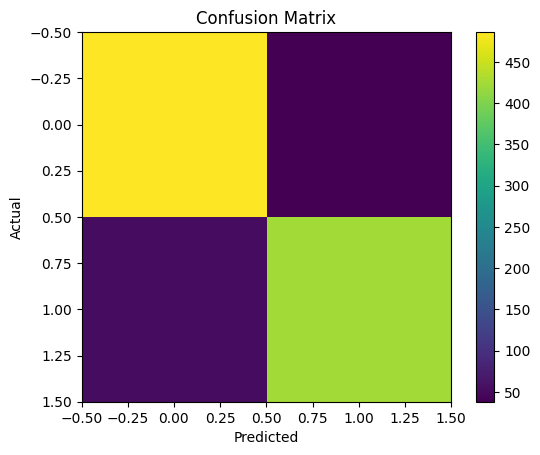

In [ ]:
cm = confusion_matrix(val_labels, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

print("BERT layers frozen. Retrain to compare results.")

BERT layers frozen. Retrain to compare results.
